# 04-03 - A First Classifier

Monday's lecture said three things about a classifier. It is a rule with adjustable numbers, training is the search for the numbers that make a loss small, and the only score that counts is the one measured on cells the model never saw. This notebook does all three on the town. It trains a random forest on the chips of 04-02, reads the forest's error matrix, holds the forest against the classifier that never looks, and then measures the same forest twice, once on a random split and once on a split by whole blocks. The second measurement is the pitfall of Lecture 02, the random split that puts neighbours on opposite sides, measured on a real classifier.

We rebuild the chips as 04-01 and 04-02 did, so that this notebook stands on its own, and we keep the forest of the lecture, a hundred trees grown with the seed the deck used, so that every score here is a score from a slide. We train on random folds and read a number near ninety six, train on blocks and read a lower one, cut the chips edge to edge and watch the gap close, ask the forest which of its sixteen numbers it used, paint its map of the town, and end with two extras. An optional cell asks a pretrained network for its 512 numbers of every chip, and the your-turn applies the August forest to March.

The ground truth file carries the numbers the lecture quoted, and every value we compute is printed beside its reference. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GroupKFold
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

reference = json.load(open("data/ground_truth.json"))["p04"]

## The chips, as 04-01 and 04-02 built them

Everything the forest sees is a row of the chip table, and 04-02 built that table from the August scene, the eight features, the town mask and the four-class labels. A notebook may not reach into another, so we build it again here with the same code, in one cell. The scene reader and the feature stack are those of 04-01, the labels collapse WorldCover as 04-02 did, and the chip rule is unchanged, sixteen cells wide, cut every eight cells, kept when nine tenths of its cells are labelled and every feature is finite, its label the majority of its cells and its sixteen numbers the mean and the spread of each feature:

In [2]:
FEATURES = ["blue", "green", "red", "nir", "swir16", "swir22", "ndvi", "ndbi"]
CLASSES = {1: "tree cover", 2: "grass", 3: "built-up", 4: "water"}
COLOURS = {1: "#2f7d32", 2: "#a8d05f", 3: "#b0413e", 4: "#3b6fb6"}
NAMES16 = [f"mean {f}" for f in FEATURES] + [f"spread {f}" for f in FEATURES]


def read_scene(date):
    '''The four 10 m bands, the two shortwave infrared bands at 20 m, and the grid, as 04-01 read them.'''
    scene = {}
    with rasterio.open(f"data/s2_{date}_town_10m.tif") as f:
        for i, name in enumerate(["blue", "green", "red", "nir"], start=1):
            scene[name] = f.read(i).astype("float32")
        scene["transform"], scene["crs"], scene["shape"] = f.transform, f.crs, (f.height, f.width)
        scene["extent"] = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)
    with rasterio.open(f"data/s2_{date}_town_20m.tif") as f:
        scene["swir16"], scene["swir22"] = f.read(1).astype("float32"), f.read(2).astype("float32")
    return scene


def features(scene):
    '''(8, rows, cols) float32 in the order of FEATURES; the 20 m bands repeated 2 by 2 onto the 10 m grid.'''
    up = lambda a: np.repeat(np.repeat(a, 2, axis=0), 2, axis=1)  # noqa: E731
    b, g, r, n = scene["blue"], scene["green"], scene["red"], scene["nir"]
    s16, s22 = up(scene["swir16"]), up(scene["swir22"])
    with np.errstate(invalid="ignore", divide="ignore"):
        ndvi = (n - r) / (n + r)
        ndbi = (s16 - n) / (s16 + n)
    stack = np.stack([b, g, r, n, s16, s22, ndvi, ndbi])
    stack[:, (r <= 0) | (n <= 0)] = np.nan
    return stack


def chip_table(feat, lab, size, stride):
    '''One row per chip: row, col, majority class, its share, then the mean and the spread of the eight features.
    A chip is kept when at least 90 percent of its cells are labelled and every feature is finite.'''
    rows, cols = lab.shape
    recs = []
    for r0 in range(0, rows - size + 1, stride):
        for c0 in range(0, cols - size + 1, stride):
            l = lab[r0:r0 + size, c0:c0 + size]
            f = feat[:, r0:r0 + size, c0:c0 + size].reshape(len(feat), -1)
            if np.mean(l > 0) < 0.9 or not np.isfinite(f).all():
                continue
            counts = np.bincount(l[l > 0], minlength=5)[1:]
            majority = int(np.argmax(counts)) + 1
            recs.append((r0, c0, majority, counts.max() / counts.sum(), *f.mean(axis=1), *f.std(axis=1)))
    return np.array(recs)


august = read_scene("20250822")
feat = features(august)
town = gpd.read_file("data/princeton_boundary.geojson").to_crs(august["crs"])
mask = rasterize([(town.geometry.iloc[0], 1)], out_shape=august["shape"], transform=august["transform"], fill=0, dtype="uint8").astype(bool)
with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    raw = f.read(1)
lab = np.zeros(raw.shape, dtype="uint8")
for code, cls in {10: 1, 30: 2, 40: 2, 90: 2, 50: 3, 80: 4}.items():
    lab[raw == code] = cls
lab[~mask] = 0

chips = chip_table(feat, lab, 16, 8)
X, y = chips[:, 4:], chips[:, 2].astype(int)
print(f"{len(chips)} chips of 16 cells, cut every 8 cells   reference {reference['chips']['overlapping']['n']}")
for c, name in CLASSES.items():
    print(f"{name:11} {int(np.sum(y == c)):5d} chips   reference {reference['chips']['overlapping']['class_counts'][name]}")

7166 chips of 16 cells, cut every 8 cells   reference 7166
tree cover   6136 chips   reference 6136
grass         645 chips   reference 645
built-up      318 chips   reference 318
water          67 chips   reference 67


Seven thousand one hundred and sixty six chips, and six of every seven are tree cover, which is the town as WorldCover sees it and the fact behind everything that follows. Keep the class counts in view, because a score is only as good as the counts it is measured against.

## The forest on a random split

Lecture 04 grew a random forest by hand on nine cells. Many trees, each grown on a random draw of the chips with replacement, so that every tree sees a slightly different town, and each question of each tree chosen among a random subset of the sixteen numbers, so that the trees differ in what they ask. The forest votes, and the class with the most votes is the answer. One tree is unsteady and memorises its training chips; a hundred trees that disagree in their details average the memorising out, which is why the forest is the first thing to try on a table of numbers.

We train it the way a first attempt always does, on five random folds. `KFold` shuffles the chips with the lecture's seed and deals them into five parts; each part is held out once while a fresh forest learns from the other four, and the score of a fold is the share of its held-out chips the forest gets right:

In [3]:
def forest():
    '''The forest of the lecture, a hundred trees, leaves of at least two chips, the deck's seed.'''
    return RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=20260928, n_jobs=-1)


def fold_scores(X, y, splits):
    '''The accuracy of a fresh forest on every held-out fold.'''
    return [float(np.mean(forest().fit(X[tr], y[tr]).predict(X[te]) == y[te])) for tr, te in splits]


random_splits = list(KFold(5, shuffle=True, random_state=20260928).split(X))
random_scores = fold_scores(X, y, random_splits)
for k, (score, ref) in enumerate(zip(random_scores, reference["forest"]["random_folds_percent"]), start=1):
    print(f"random fold {k}: {100 * score:.1f} percent of {len(random_splits[k - 1][1])} held-out chips right   reference {ref}")
print(f"mean over the five random folds {100 * np.mean(random_scores):.1f} percent   reference {reference['forest']['random_mean_percent']}")

random fold 1: 95.7 percent of 1434 held-out chips right   reference 95.7
random fold 2: 96.7 percent of 1433 held-out chips right   reference 96.7
random fold 3: 96.2 percent of 1433 held-out chips right   reference 96.2
random fold 4: 95.6 percent of 1433 held-out chips right   reference 95.6
random fold 5: 95.8 percent of 1433 held-out chips right   reference 95.8
mean over the five random folds 96.0 percent   reference 96.0


Five folds, five scores within a point of one another, a mean near ninety six percent, and the reference beside every line. A number like that sounds like a solved problem, and everything from here to the end of the notebook is about why it is not. Three things hide inside it. The town is six sevenths tree cover, so a large part of the score is free. The folds were dealt at random, so almost every held-out chip has a training chip beside it. And the chips overlap by half, so many held-out chips share their very cells with a training chip. We take the three apart in turn, and we start by looking at what the forest gets wrong rather than at how often.

## The error matrix

The lecture read the error matrix on two classes first and then on four, and this is the four-class reading on the chips. An honest matrix needs a hold-out that is not the neighbour of the training set, so we take the first of five folds of whole blocks, three kilometres square, the range of the semivariogram of Lecture 02. `GroupKFold` keeps every block whole, the chips of four folds of blocks train the forest and the fifth fold is held out, and the matrix counts the held-out chips by what they are, the rows, and by what the forest called them, the columns:

10 blocks of 3 km over the town   reference 10
first block fold: 5799 chips train the forest, 1367 are held out   reference 5799, 1367
overall accuracy on the held-out chips 90.1 percent   reference 90.1
tree cover  producer's accuracy  96.5   reference 96.5     user's accuracy  91.2   reference 91.2
grass       producer's accuracy  79.3   reference 79.3     user's accuracy  94.2   reference 94.2
built-up    producer's accuracy  67.0   reference 67.0     user's accuracy  79.8   reference 79.8
water       producer's accuracy  none   reference none     user's accuracy  none   reference none


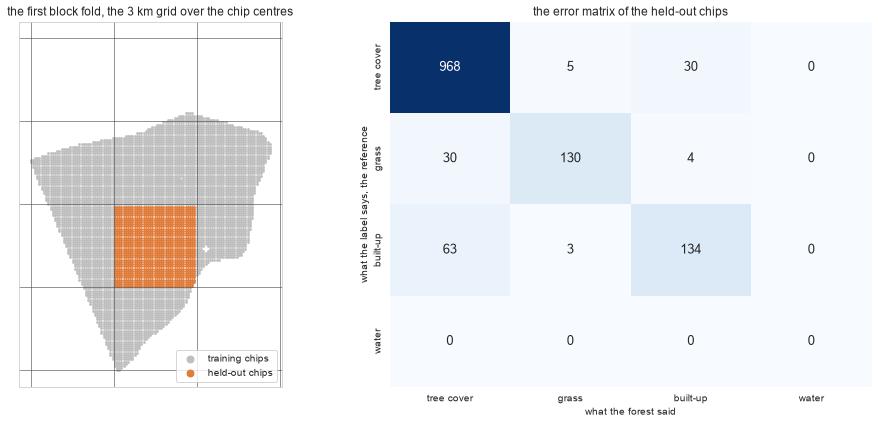

In [4]:
def chip_centres(table, transform, size=16):
    '''The centre of every chip in the scene's coordinates.'''
    xs, ys = transform * (table[:, 1] + size / 2, table[:, 0] + size / 2)
    return np.asarray(xs), np.asarray(ys)


def blocks(xs, ys, size):
    '''Block ids of a grid of `size` metres over the points.'''
    return ((xs - xs.min()) // size).astype(int) * 1000 + ((ys - ys.min()) // size).astype(int)


def error_matrix(y_true, y_pred, classes=(1, 2, 3, 4)):
    '''Rows the reference classes, columns what the classifier said, in the order of classes.'''
    return np.array([[int(np.sum((y_true == ci) & (y_pred == cj))) for cj in classes] for ci in classes])


def accuracies(m):
    '''Overall, producer's and user's accuracy of an error matrix; nan for a class with no chip in a row or a column.'''
    m = np.asarray(m, dtype=float)
    diag, rows, cols = np.diag(m), m.sum(axis=1), m.sum(axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        producers = np.where(rows > 0, diag / rows, np.nan)
        users = np.where(cols > 0, diag / cols, np.nan)
    return dict(overall=float(diag.sum() / m.sum()), producers=producers, users=users)


xs, ys = chip_centres(chips, august["transform"])
groups = blocks(xs, ys, 3000)
block_splits = list(GroupKFold(5).split(X, y, groups))
train, test = block_splits[0]
model = forest().fit(X[train], y[train])
pred = model.predict(X[test])
matrix = error_matrix(y[test], pred)
acc = accuracies(matrix)
fold = reference["forest"]["first_block_fold"]

print(f"{len(np.unique(groups))} blocks of 3 km over the town   reference {reference['forest']['blocks_n']}")
print(f"first block fold: {len(train)} chips train the forest, {len(test)} are held out   reference {fold['n_train']}, {fold['n_test']}")
print(f"overall accuracy on the held-out chips {100 * acc['overall']:.1f} percent   reference {fold['accuracy_percent']}")
as_text = lambda v: "none" if v is None or np.isnan(v) else f"{100 * v:.1f}"    # noqa: E731
as_ref = lambda v: "none" if v is None else v                                  # noqa: E731
for i, (c, name) in enumerate(CLASSES.items()):
    print(f"{name:11} producer's accuracy {as_text(acc['producers'][i]):>5}   reference {as_ref(fold['producers_percent'][name])}"
          f"     user's accuracy {as_text(acc['users'][i]):>5}   reference {as_ref(fold['users_percent'][name])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
ax.scatter(xs[train], ys[train], s=3, color="0.75", label="training chips")
ax.scatter(xs[test], ys[test], s=3, color="#e07b39", label="held-out chips")
for k in range(int((xs.max() - xs.min()) // 3000) + 2):
    ax.axvline(xs.min() + k * 3000, color="0.3", linewidth=0.6)
for k in range(int((ys.max() - ys.min()) // 3000) + 2):
    ax.axhline(ys.min() + k * 3000, color="0.3", linewidth=0.6)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower right", markerscale=4, fontsize=10)
ax.set_title("the first block fold, the 3 km grid over the chip centres", fontsize=12)
names = list(CLASSES.values())
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=names, yticklabels=names, ax=axes[1], annot_kws={"size": 13})
axes[1].set_xlabel("what the forest said"); axes[1].set_ylabel("what the label says, the reference")
axes[1].set_title("the error matrix of the held-out chips", fontsize=12)
fig.tight_layout()

The held-out block is the one in the middle of the town, with the town centre and the campus in it, and the matrix is read the lecture's way. The diagonal is the chips the forest got right, and overall accuracy is the diagonal over the total, ninety point one percent on the reference. Then one class at a time. Producer's accuracy, of the real chips of a class the share the forest found, also called recall, is the row's diagonal over the row. User's accuracy, of the chips the forest calls a class the share that really are, also called precision and the number the user of the map wants, is the column's diagonal over the column. Tree cover is found almost completely, and when the forest says tree cover it is right nine times in ten. Grass and built-up are where the errors are. A fifth of the grass chips and a third of the built-up chips were called tree cover, because a window of 160 metres in this town almost always holds trees, and a chip whose majority is lawn or roofs still carries the signal of the trees between them. Water has an empty row and an empty column, and both of its accuracies print none, because the held-out block of this fold contains no water chip. A matrix can only be read for the classes that were held out, and a fold that misses a class says nothing about it.

## The majority baseline

The lecture's beat was the classifier that never looks. It says tree cover for every chip, and on a town that is six sevenths tree cover it scores well without a single feature. We compute it twice, on all the chips and on the held-out block of this fold, because a baseline belongs to the test set it is compared on:

In [5]:
majority = int(np.bincount(y[train]).argmax())
print(f"the majority class of the training chips is {CLASSES[majority]}   reference {fold['majority_class']}")
print(f"{CLASSES[majority]} everywhere scores {100 * np.mean(y == majority):.1f} percent on all chips   reference {reference['chips']['overlapping']['majority_class_percent']}")
print(f"{CLASSES[majority]} everywhere scores {100 * np.mean(y[test] == majority):.1f} percent on the held-out block of this fold   reference {fold['majority_percent']}")
print(f"the forest scores {100 * acc['overall']:.1f} percent on the same block   reference {fold['accuracy_percent']}")

the majority class of the training chips is tree cover   reference tree cover
tree cover everywhere scores 85.6 percent on all chips   reference 85.6
tree cover everywhere scores 73.4 percent on the held-out block of this fold   reference 73.4
the forest scores 90.1 percent on the same block   reference 90.1


On all chips the baseline is the majority share of the table, eighty five point six percent on the reference, which is most of the way to the random split's ninety six. On the held-out block of this fold it is lower, seventy three point four, because the central block holds more lawns and roofs than the town's average, and the forest's ninety point one is judged against that number and no other. Seventeen points above the baseline is a classifier that learned something. Ninety percent on its own is not a statement, since the classifier that never looks gets most of the way there. A high accuracy on an unbalanced town says little until the baseline is written beside it, and the baseline is the first number your proposal reports.

## The split by whole blocks

Now the second thing hidden in ninety six. The random folds dealt the chips without regard to where they lie, and Lecture 02 counted what that does. A random split puts eighty percent of neighbouring pairs on opposite sides, blocks of three kilometres eleven percent. A forest trained beside its test chips has seen their neighbourhood, and the score then measures memory as much as generalisation. The five folds of whole blocks are the same forest, the same chips and the same scoring, with only the dealing changed:

block fold 1: 90.1 percent right   reference 90.1     1367 held-out chips in 1 block(s), 73.4 percent of them tree cover
block fold 2: 97.1 percent right   reference 97.1     1338 held-out chips in 2 block(s), 91.6 percent of them tree cover
block fold 3: 97.3 percent right   reference 97.3     1356 held-out chips in 3 block(s), 92.5 percent of them tree cover
block fold 4: 95.6 percent right   reference 95.6     1521 held-out chips in 2 block(s), 90.6 percent of them tree cover
block fold 5: 94.5 percent right   reference 94.5     1584 held-out chips in 2 block(s), 80.5 percent of them tree cover
mean over the five block folds  94.9 percent   reference 94.9
mean over the five random folds 96.0 percent   reference 96.0
the block folds range from 90.1 to 97.3, the random folds from 95.6 to 96.7


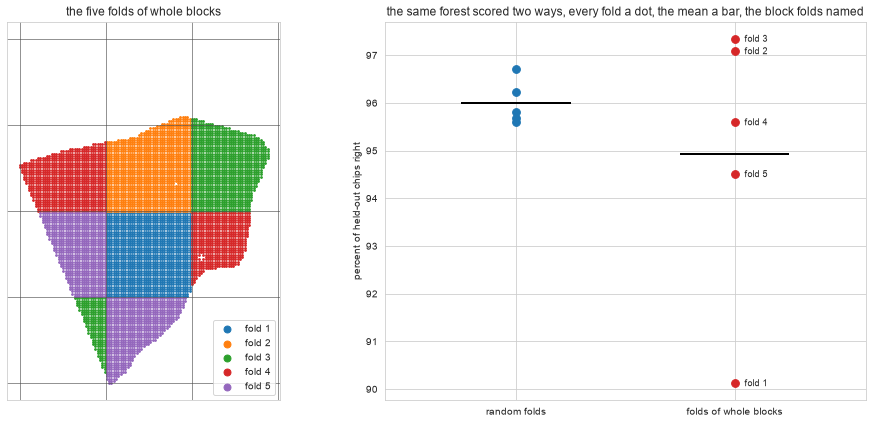

In [6]:
block_scores = fold_scores(X, y, block_splits)
for k, (score, ref) in enumerate(zip(block_scores, reference["forest"]["blocked_folds_percent"]), start=1):
    held = block_splits[k - 1][1]
    print(f"block fold {k}: {100 * score:.1f} percent right   reference {ref}"
          f"     {len(held)} held-out chips in {len(np.unique(groups[held]))} block(s), {100 * np.mean(y[held] == 1):.1f} percent of them tree cover")
print(f"mean over the five block folds  {100 * np.mean(block_scores):.1f} percent   reference {reference['forest']['blocked_mean_percent']}")
print(f"mean over the five random folds {100 * np.mean(random_scores):.1f} percent   reference {reference['forest']['random_mean_percent']}")
print(f"the block folds range from {100 * min(block_scores):.1f} to {100 * max(block_scores):.1f}, the random folds from {100 * min(random_scores):.1f} to {100 * max(random_scores):.1f}")

fold_of = np.zeros(len(chips), dtype=int)
for k, (tr, te) in enumerate(block_splits, start=1):
    fold_of[te] = k
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
for k in range(1, 6):
    ax.scatter(xs[fold_of == k], ys[fold_of == k], s=3, color=f"C{k - 1}", label=f"fold {k}")
for k in range(int((xs.max() - xs.min()) // 3000) + 2):
    ax.axvline(xs.min() + k * 3000, color="0.3", linewidth=0.6)
for k in range(int((ys.max() - ys.min()) // 3000) + 2):
    ax.axhline(ys.min() + k * 3000, color="0.3", linewidth=0.6)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower right", markerscale=4, fontsize=10)
ax.set_title("the five folds of whole blocks", fontsize=12)
ax = axes[1]
for x0, scores, label in ((0, random_scores, "random folds"), (1, block_scores, "folds of whole blocks")):
    ax.scatter(np.full(5, x0), 100 * np.array(scores), s=60, zorder=3, color="C0" if x0 == 0 else "C3")
    ax.hlines(100 * np.mean(scores), x0 - 0.25, x0 + 0.25, color="black", linewidth=2)
for k, s in enumerate(block_scores, start=1):
    ax.annotate(f"fold {k}", (1, 100 * s), xytext=(10, -3), textcoords="offset points", fontsize=9)
ax.set_xlim(-0.6, 1.6); ax.set_xticks([0, 1]); ax.set_xticklabels(["random folds", "folds of whole blocks"])
ax.set_ylabel("percent of held-out chips right")
ax.set_title("the same forest scored two ways, every fold a dot, the mean a bar, the block folds named", fontsize=12)
fig.tight_layout()

The mean falls by about a point, from ninety six to near ninety five on the reference, where the lecture's forest on cells fell by three. The message is in the spread rather than in the mean. The random folds lie within a point of one another, and the block folds range over seven, because a block is a real part of the town with its own mix of woods, lawns and roofs, and the forest does better or worse depending on which part it has never seen. Look at the tree cover share printed beside each fold. The two highest scores belong to the eastern blocks that are almost entirely trees, where the classifier that never looks would have scored above ninety on its own. The lowest is the central block we read the matrix on, where a quarter of the held-out chips are lawns and roofs and the forest has to earn its score. The western blocks, with the most grass and hardly a roof among them, come second from the bottom. That range is what the random split hides. With neighbours on both sides of every cut, every random fold looks like every other, and the steadiness of the five random scores is a property of the dealing, not of the forest.

The third thing hidden in ninety six is the overlap. A chip cut every eight cells shares half of its cells with the chip before it and half with the chip after, so a held-out chip and a training chip can be the same 128 cells plus a different 128, and the forest has half seen it. Cut the chips edge to edge instead, at a stride of sixteen, and there is nothing left to share. The table has a quarter as many rows, and the two scorings are repeated on it unchanged:

In [7]:
tiled = chip_table(feat, lab, 16, 16)
Xt, yt = tiled[:, 4:], tiled[:, 2].astype(int)
tx, ty = chip_centres(tiled, august["transform"])
tiled_random = fold_scores(Xt, yt, list(KFold(5, shuffle=True, random_state=20260928).split(Xt)))
tiled_block = fold_scores(Xt, yt, list(GroupKFold(5).split(Xt, yt, blocks(tx, ty, 3000))))
print(f"{len(tiled)} chips edge to edge   reference {reference['chips']['tiled']['n']}")
print(f"random folds on the edge-to-edge chips {100 * np.mean(tiled_random):.1f} percent   reference {reference['forest']['tiled_random_mean_percent']}")
print(f"block folds on the edge-to-edge chips  {100 * np.mean(tiled_block):.1f} percent   reference {reference['forest']['tiled_blocked_mean_percent']}")
print(f"on the overlapping chips the two were {100 * np.mean(random_scores):.1f} and {100 * np.mean(block_scores):.1f}")

1791 chips edge to edge   reference 1791
random folds on the edge-to-edge chips 95.3 percent   reference 95.3
block folds on the edge-to-edge chips  94.8 percent   reference 94.8
on the overlapping chips the two were 96.0 and 94.9


With no overlap the random mean falls and the block mean hardly moves, and the two are half a point apart on the reference where the overlapping chips had a full point between them. That closing gap is what the overlap leaked. The random split overestimates for the reason the lecture gave, neighbouring chips share cells and look alike, and an overlapping chip is the extreme neighbour, the one that shares the cells themselves. The blocked score barely notices, because a block boundary separates whole neighbourhoods and the chips that straddle it are few. Three lessons, then, from one number. Report the baseline beside the accuracy. Hold out by place if the question is about other places. And cut your chips so that the test set does not contain half of the training set.

## What the forest looked at

A forest can say which of its numbers it used. Every question in every tree makes the groups behind it purer, and the impurity a feature removed, summed over all the questions that asked about it in all the trees, is its importance; the sixteen importances add up to one. Lecture 04 printed them for the forest on cells, with the shortwave infrared band first. Here they are for the forest of the first block fold, on the sixteen numbers of a chip:

the three most used numbers: mean swir16, mean nir, mean ndvi   reference mean swir16, mean nir, mean ndvi
mean swir16  24.7 percent of the impurity removed   reference 24.7
mean nir     17.6 percent of the impurity removed   reference 17.6
mean ndvi    9.4 percent of the impurity removed   reference 9.4
the eight means together 77.3 percent, the eight spreads together 22.7


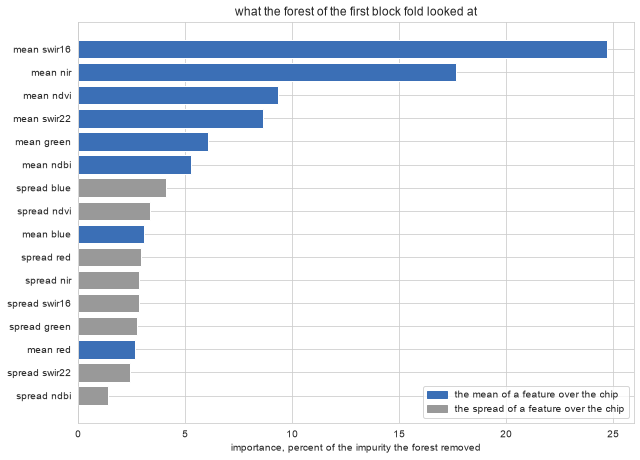

In [8]:
importances = pd.Series(model.feature_importances_, index=NAMES16)
top_three = list(importances.sort_values(ascending=False).index[:3])
print(f"the three most used numbers: {', '.join(top_three)}   reference {', '.join(fold['top_three'])}")
for name in top_three:
    print(f"{name:12} {100 * importances[name]:.1f} percent of the impurity removed   reference {fold['importances_percent'][name]}")
print(f"the eight means together {100 * importances[:8].sum():.1f} percent, the eight spreads together {100 * importances[8:].sum():.1f}")

order = importances.sort_values()
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(order.index, 100 * order.values, color=["#3b6fb6" if name.startswith("mean") else "0.6" for name in order.index])
ax.set_xlabel("importance, percent of the impurity the forest removed")
ax.set_title("what the forest of the first block fold looked at", fontsize=12)
ax.legend(handles=[Patch(color="#3b6fb6", label="the mean of a feature over the chip"), Patch(color="0.6", label="the spread of a feature over the chip")], loc="lower right", fontsize=10)
fig.tight_layout()

The mean of the shortwave infrared band leads, as it did on the cells, and the mean of near infrared and the mean of NDVI follow. Shortwave infrared is where water and built-up separate from everything green. Water absorbs it almost completely and roofs and asphalt reflect it, so one number sorts the two rare classes from the trees, and near infrared and NDVI then split grass from trees by how much leaf is in the chip. The eight spreads together carry less than the mean of shortwave infrared alone, which says something about the chips rather than about the features. At sixteen cells of ten metres a chip is too small for its texture to matter, and its mean colour is nearly all the forest needs. Importances say what this forest used on these chips, not what matters in nature; grow the forest on cells instead of chips, or on March instead of August, and the order changes.

## The map from the chips

The forest can predict every chip, and a class for every chip is a map at the chips' resolution. We paint each chip's central eight by eight cells with its predicted class, in reading order so that a later chip overwrites an earlier one, and set the result beside the labels painted the same way and beside the labels at ten metres:

on its 5799 training chips the forest is right 99.7 percent of the time
on the 1367 held-out chips it is right 90.1 percent of the time   reference 90.1
tree cover   86.6 percent of the chips by the forest,  85.6 by the labels
grass         8.5 percent of the chips by the forest,   9.0 by the labels
built-up      4.0 percent of the chips by the forest,   4.4 by the labels
water         0.9 percent of the chips by the forest,   0.9 by the labels


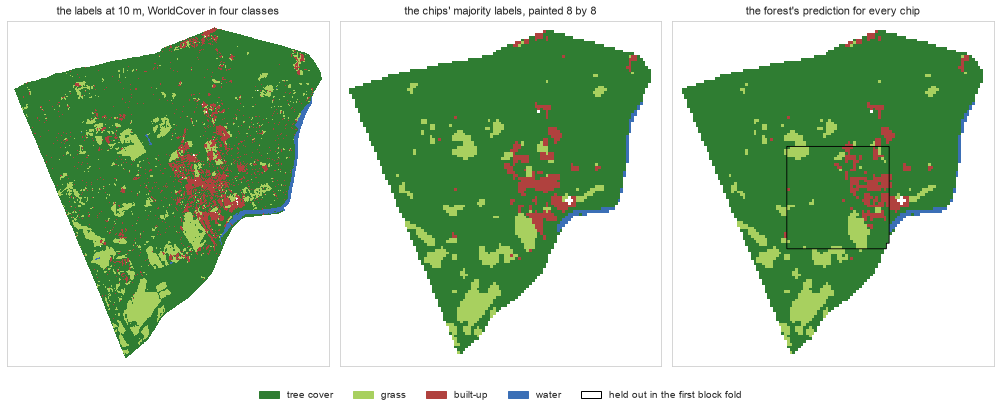

In [9]:
def paint(table, classes, shape, size=16):
    '''A map at chip resolution: every chip's central 8 by 8 cells take its class, in reading order, so a later chip overwrites an earlier one.'''
    out = np.zeros(shape, dtype="uint8")
    q = size // 4
    for (r0, c0), cls in zip(table[:, :2].astype(int), classes):
        out[r0 + q:r0 + size - q, c0 + q:c0 + size - q] = cls
    return out


everywhere = model.predict(X)
predicted = paint(chips, everywhere, lab.shape)
majority_map = paint(chips, y, lab.shape)
held_out = paint(chips[test], np.ones(len(test), dtype=int), lab.shape)
print(f"on its {len(train)} training chips the forest is right {100 * np.mean(everywhere[train] == y[train]):.1f} percent of the time")
print(f"on the {len(test)} held-out chips it is right {100 * np.mean(everywhere[test] == y[test]):.1f} percent of the time   reference {fold['accuracy_percent']}")
for c, name in CLASSES.items():
    print(f"{name:11} {100 * np.mean(everywhere == c):5.1f} percent of the chips by the forest, {100 * np.mean(y == c):5.1f} by the labels")

cmap = ListedColormap(["white", COLOURS[1], COLOURS[2], COLOURS[3], COLOURS[4]])
left, right, bottom, top = august["extent"]
cell_x = left + (np.arange(lab.shape[1]) + 0.5) * 10
cell_y = top - (np.arange(lab.shape[0]) + 0.5) * 10
fig, axes = plt.subplots(1, 3, figsize=(14, 5.6))
panels = (("the labels at 10 m, WorldCover in four classes", lab), ("the chips' majority labels, painted 8 by 8", majority_map), ("the forest's prediction for every chip", predicted))
for ax, (title, image) in zip(axes, panels):
    ax.imshow(image, cmap=cmap, vmin=0, vmax=4, interpolation="nearest", extent=august["extent"])
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
axes[2].contour(cell_x, cell_y, held_out, levels=[0.5], colors="black", linewidths=0.9)
fig.legend(handles=[Patch(color=COLOURS[c], label=name) for c, name in CLASSES.items()] + [Patch(facecolor="white", edgecolor="black", label="held out in the first block fold")],
           loc="lower center", ncol=5, frameon=False, fontsize=10)
fig.tight_layout(rect=(0, 0.06, 1, 1))

The forest's map is nearly the chips' majority map, and it should be, because on its training chips the forest is right almost every time, as the first printed line says, while inside the outline, the held-out block, it scores what the matrix said. That is the difference between a training accuracy and a test. Compare the three panels. The left one, the labels at ten metres, has red along every residential street and around every scattered house. The middle one, the same labels at the chips' resolution, has lost nearly all of it, because a window of 160 metres in a leafy suburb is trees by majority, and only the centre, the shopping streets and the campus survive as red. The forest inherits that map and rounds it a little further toward tree cover, a little more green and a little less grass and red than the labels, as the printed shares say and as the error matrix predicted. A map made from the training area's own chips is a picture of what the forest memorised, not a test, and a report that shows such a map with a training accuracy beside it has shown nothing yet. The honest part of this map is the part inside the outline.

## What a pretrained network adds

The lecture gave two ways to turn a chip into numbers. Twelve or sixteen numbers a person named, the means and spreads of the bands, which is what the forest above used. Or 512 numbers a network learned on photographs, the last list of a convolutional network trained on ImageNet, which nobody named and which told trees from grass where the twelve could not. This cell is the frozen way of the lecture. The network stays as it is and is called as a function, a chip of red, green and blue goes in and 512 numbers come out, and the forest is trained on those. The course environment does not carry the deep learning library, so the cell will most likely stop after one sentence; it runs in the environment of P05, and it is here so that you can see what the call looks like. If the library is present, it scales every chip's three visible bands to the range of the scene, enlarges the sixteen by sixteen chip to the 224 by 224 cells the network expects, normalises it the way the network's photographs were normalised, passes the chips through in batches, and then trains the same forest three times on the same first block fold, on the sixteen numbers, on the 512, and on both:

In [10]:
try:
    import torch
    import torchvision
    from torchvision.models import resnet18, ResNet18_Weights
    network = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)     # the weights are fetched once and cached
    network.fc = torch.nn.Identity()                                  # drop the last layer and keep the 512 numbers before it
    network.eval()
    ready = True
except Exception:                                                     # the library is missing, or the weights could not be fetched
    ready = False
    print("The deep learning library is not part of the course environment, so this cell stops here; it runs in the environment of P05 on 7 October.")

if ready:
    try:
        top_98 = float(np.percentile(np.stack([august["red"], august["green"], august["blue"]])[:, mask], 98))
        pictures = np.stack([np.stack([august[band][r0:r0 + 16, c0:c0 + 16] for band in ("red", "green", "blue")]) for r0, c0 in chips[:, :2].astype(int)])
        pictures = np.clip(pictures / top_98, 0, 1).astype("float32")          # (chips, 3, 16, 16), 0 to 1
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)           # what the network's photographs were normalised with
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        learned = []
        with torch.no_grad():
            for start in range(0, len(pictures), 256):
                batch = torch.from_numpy(pictures[start:start + 256])
                batch = torch.nn.functional.interpolate(batch, size=(224, 224), mode="bilinear", align_corners=False)
                learned.append(network((batch - mean) / std).numpy())
        Z = np.concatenate(learned)
        print(f"{Z.shape[0]} chips, {Z.shape[1]} learned numbers each, from {torchvision.__version__} of torchvision")
        for name, table in (("the sixteen numbers", X), ("the 512 learned numbers", Z), ("the sixteen plus the 512", np.hstack([X, Z]))):
            score = float(np.mean(forest().fit(table[train], y[train]).predict(table[test]) == y[test]))
            print(f"{name:26} {100 * score:.1f} percent on the held-out block of the first fold" + (f"   reference {fold['accuracy_percent']}" if table is X else ""))
    except Exception as problem:
        print(f"The network is installed but could not be run here ({type(problem).__name__}), so this cell stops; it runs in the environment of P05 on 7 October.")

The deep learning library is not part of the course environment, so this cell stops here; it runs in the environment of P05 on 7 October.


If one sentence printed, that is the whole output, and the comparison waits for 7 October. If three scores printed, read them against one another. The 512 numbers of a network that has never seen a satellite image, on chips of sixteen cells enlarged fourteen times, are not expected to beat sixteen numbers that carry the shortwave infrared the network never sees, and the third forest, on both, says whether the learned numbers add anything the means and spreads lack. Either way the point of the cell is the shape of the call. A pretrained network is a function from a picture to a list of numbers, and everything you know about the forest applies to that list unchanged.

## Your turn

Apply the August forest to March. The leaf-off scene of 10 March 2025 is in the data folder under the same names with the other date, and the same code cuts it into chips on the same labels, since the town did not change between March and August. Train the forest on every August chip, because the test is now a different month rather than a different place, predict the March chips, and print the share of chips predicted in each class beside the share labelled in each class in August. The sentence to write is what changed and what did not, and what a model trained on one date is a model of.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [11]:
# Your attempt. read_scene, features and chip_table are defined above, lab holds the August labels, and forest() makes the lecture's forest.
#
# march = read_scene("___")                                    # the leaf-off scene; the file names in data carry the date
# chips_march = chip_table(features(march), lab, ___, ___)    # the same chips on the same labels
# full = forest().fit(X, y)                                    # every August chip, since the test is a different month, not a different place
# pred_march = full.predict(chips_march[:, 4:])
# for c, name in CLASSES.items():
#     print(f"{name:11} predicted in March {np.mean(pred_march == c):6.1%}   labelled in August {np.mean(y == ___):6.1%}")

## Check your understanding

1. The random folds scored the forest near ninety six percent and the block folds lower. Which of the two answers the question "how well will this forest map a neighbourhood it was not trained on", and which question does the other one answer?
2. In the first block fold the forest scored ninety percent against a baseline of seventy three. A colleague's classifier scores ninety two percent on a fold whose baseline is eighty eight. Which classifier learned more, and why is a comparison of the two raw scores meaningless?
3. Water's producer's and user's accuracy printed none. What would you change about the split, not the forest, to get a number for water, and what would it cost the other classes?
4. The edge-to-edge chips scored lower than the overlapping ones on the random split and about the same on the block split. Explain each movement in one sentence that uses the word neighbour.

## Where we are

You can train a random forest on a table of chips and score it with cross-validation. You can read an error matrix by rows and by columns, compute overall, producer's and user's accuracy from it, and say which class the matrix cannot speak for. You can compute the majority baseline for the test set at hand and judge an accuracy against it. You have measured the same forest on a random split and on a split by whole blocks, seen the gap and the spread, and traced part of the gap to the overlap of the chips. And you have asked the forest what it used, painted its map, seen how a frozen network is called, and applied a model of one month to another.

The habit worth keeping: report every accuracy beside its baseline and beside the split that produced it, and hold out by place whenever the question is about a place the model has not seen.

This is the last notebook of the kit. P05 on 7 October segments the town with a network, and the proposal you hand in today is written in this notebook's words: the task, the labels, the split, the baseline.

## Further resources

Nothing in this course requires anything below.

Géron, Hands-On Machine Learning with Scikit-Learn and PyTorch (2025), chapters 2, 3 and 6, is the book behind the forest, the error matrix and cross-validation, at greater length and with the code. Chapter 7 of Wu, GeoAI with Python, trains the same kind of classifier on satellite imagery and is on the course reading list, at https://book.opengeoai.org

The handbook chapter on spatial cross-validation, which the lecture quoted for the published gaps between random and spatial validation, is an open preprint at http://acsu.buffalo.edu/~yhu42/papers/2023_GeoAIHandbook_SpatialCV.pdf

The scikit-learn user guide on cross-validation documents every splitter used here, `KFold` and `GroupKFold` among them, at https://scikit-learn.org/stable/modules/cross_validation.html

The Sentinel-2 files in this folder contain modified Copernicus Sentinel data 2025. The land cover map is ESA WorldCover 2021 v200 (Zanaga et al. 2022, CC BY 4.0). The municipal boundary is a public record of NJGIN.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The August forest on the March chips, built from the files so that the cell stands on its own. It reads both scenes and cuts both chip tables, so it takes a little while:

```python
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from sklearn.ensemble import RandomForestClassifier


def read_scene(date):
    scene = {}
    with rasterio.open(f"data/s2_{date}_town_10m.tif") as f:
        for i, name in enumerate(["blue", "green", "red", "nir"], start=1):
            scene[name] = f.read(i).astype("float32")
        scene["transform"], scene["crs"], scene["shape"] = f.transform, f.crs, (f.height, f.width)
    with rasterio.open(f"data/s2_{date}_town_20m.tif") as f:
        scene["swir16"], scene["swir22"] = f.read(1).astype("float32"), f.read(2).astype("float32")
    return scene


def features(scene):
    up = lambda a: np.repeat(np.repeat(a, 2, axis=0), 2, axis=1)
    b, g, r, n = scene["blue"], scene["green"], scene["red"], scene["nir"]
    s16, s22 = up(scene["swir16"]), up(scene["swir22"])
    with np.errstate(invalid="ignore", divide="ignore"):
        ndvi = (n - r) / (n + r)
        ndbi = (s16 - n) / (s16 + n)
    stack = np.stack([b, g, r, n, s16, s22, ndvi, ndbi])
    stack[:, (r <= 0) | (n <= 0)] = np.nan
    return stack


def chip_table(feat, lab, size, stride):
    rows, cols = lab.shape
    recs = []
    for r0 in range(0, rows - size + 1, stride):
        for c0 in range(0, cols - size + 1, stride):
            l = lab[r0:r0 + size, c0:c0 + size]
            f = feat[:, r0:r0 + size, c0:c0 + size].reshape(len(feat), -1)
            if np.mean(l > 0) < 0.9 or not np.isfinite(f).all():
                continue
            counts = np.bincount(l[l > 0], minlength=5)[1:]
            recs.append((r0, c0, int(np.argmax(counts)) + 1, counts.max() / counts.sum(), *f.mean(axis=1), *f.std(axis=1)))
    return np.array(recs)


august, march = read_scene("20250822"), read_scene("20250310")
town = gpd.read_file("data/princeton_boundary.geojson").to_crs(august["crs"])
mask = rasterize([(town.geometry.iloc[0], 1)], out_shape=august["shape"], transform=august["transform"], fill=0, dtype="uint8").astype(bool)
with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    raw = f.read(1)
lab = np.zeros(raw.shape, dtype="uint8")
for code, cls in {10: 1, 30: 2, 40: 2, 90: 2, 50: 3, 80: 4}.items():
    lab[raw == code] = cls
lab[~mask] = 0

chips = chip_table(features(august), lab, 16, 8)
chips_march = chip_table(features(march), lab, 16, 8)
X, y = chips[:, 4:], chips[:, 2].astype(int)
full = RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=20260928, n_jobs=-1).fit(X, y)
pred_march = full.predict(chips_march[:, 4:])
for c, name in {1: "tree cover", 2: "grass", 3: "built-up", 4: "water"}.items():
    print(f"{name:11} predicted in March {np.mean(pred_march == c):6.1%}   labelled in August {np.mean(y == c):6.1%}")
```

The town did not change between the two dates, and the labels are the same rows of the same table, yet in March most of the chips come out as grass and about a fifth as built-up, with tree cover reduced to a quarter of what August labelled. The deciduous trees have no leaves in March, so a chip of bare canopy reflects like the dormant lawn or the roofs the forest learned in August, and the forest has no way to know that the season, not the town, is what moved. The lecture's forest on single cells called the same March scene almost entirely built-up; this one, with the mean over a whole chip and the spread beside it, calls it mostly grass, and neither map is the town. A model is tied to the date, the sensor and the place of its training data, which is the last sentence of Lecture 04 and the first question to ask of any model your project borrows.